In [169]:
# Import necessary libraries
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf


In [170]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train.shape # 60000 images of size 28X28

(60000, 28, 28)

## Data Augmentation 

In [171]:
# Normalize and expand dims for Keras data augmentation
first_image = x_train[0]
# Normalize pixel values to [0, 1]
normalise_image = first_image.astype('float32')/255.0
normalise_image = np.expand_dims(normalise_image, axis = (0,-1)) # expand to 1 x 28 x 28 x 1
normalise_image.shape 


(1, 28, 28, 1)

Define Rotation layer

In [172]:
# Random rotation augmentation
rotation_layer = keras.layers.RandomRotation(factor = 0.1)
rotated_image = rotation_layer(normalise_image)

Text(0.5, 1.0, 'Rotated image')

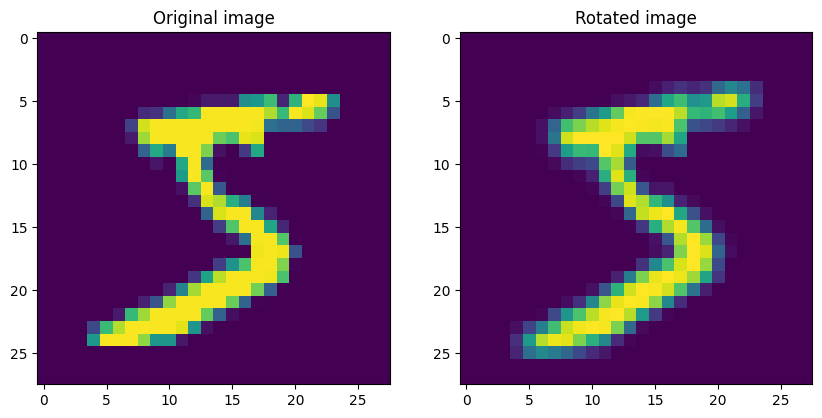

In [173]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(x_train[0])
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(rotated_image.numpy().squeeze())
plt.title('Rotated image')



Random Translation layer 

In [174]:
# Random translation augmentation
translation_layer = keras.layers.RandomTranslation(height_factor=0.5, width_factor=0.5)
translated_image = translation_layer(normalise_image)

Text(0.5, 1.0, 'Translated image')

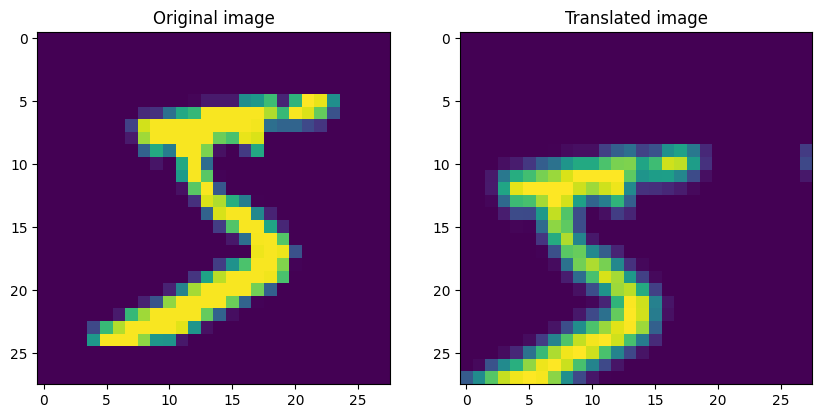

In [175]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(x_train[0])
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(translated_image.numpy().squeeze())
plt.title('Translated image')

## Feature extraction using PCA


To apply Principal Component Analysis, we have to centralise the data

In [176]:
# Flatten images from 28x28 to 784
x_train_reshaped = tf.cast(tf.reshape(x_train, [-1, 784]), tf.float32)
# Calculate the mean of the training set
mean = tf.reduce_mean(x_train_reshaped, axis = 0)
x_centered = x_train_reshaped - mean



Calculating the covariance matrix

Covariance matrix = $\frac{X^TX}{N-1}$ 
where N = total number of data

In [177]:
# N is the number of samples
N = tf.cast(np.shape(x_centered)[0], tf.float32) 
# Compute the sample covariance matrix
cov_matrix = tf.matmul(tf.transpose(x_centered), x_centered)/(N-1)
cov_matrix

<tf.Tensor: shape=(784, 784), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 784), dtype=float32)>

Calculating the eigen vectors and eigen values

In [178]:
# Compute eigenvalues and eigenvectors
eigen_values, eigen_vectors = tf.linalg.eigh(cov_matrix)
eigen_values

<tf.Tensor: shape=(784,), dtype=float32, numpy=
array([-7.00123049e-03, -6.20110659e-03, -3.99488397e-03, -3.65191442e-03,
       -2.76664714e-03, -2.00967514e-03, -1.34032150e-03, -1.22390687e-03,
       -9.86511353e-04, -7.93740095e-04, -6.49254827e-04, -4.99753747e-04,
       -3.39131540e-04, -2.40673020e-04, -1.43167956e-04, -8.90521624e-05,
       -5.06118995e-05, -1.53104429e-05, -1.10791516e-05, -1.13714373e-06,
       -3.13532666e-07, -2.45841107e-07, -1.37583925e-07, -4.31630447e-08,
       -2.22549428e-08, -1.88157809e-08, -1.14871024e-09, -6.75329292e-10,
       -1.13890180e-12,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.54161758e-13,  3.40804614e-13,  1.03449855e-12,
        1.80121413e-12,  3.17000874e-12,  1.73756107

Here the eigenvalues are in ascending order. We sort them in descending order.

In [179]:
# Sort eigenvalues in descending order
eigen_values = eigen_values[::-1]
# Sort eigenvectors to match
eigen_vectors = eigen_vectors[:, ::-1]

Choosing k = 50 dominant eigenvalues (features).

Taking the corresponding eigenvectors to form a new projection matrix W of shape (784, 50).

In [180]:
k = 50
# Select top k eigenvectors to form projection matrix W
w = eigen_vectors[:, :k]

the projection matrix $ Y = X \cdot W$

In [181]:
# Project the centered data onto the principal components
x_pca = tf.matmul(x_centered, w)
print("Original data shape:", x_train.shape)
print("PCA projected shape:", x_pca.shape)

Original data shape: (60000, 28, 28)
PCA projected shape: (60000, 50)


## Apply LBP and HOG

In [182]:
from skimage.feature import local_binary_pattern
from skimage import color
# Extract Local Binary Pattern features for an array of images
def extract_LBP_features(images):
    lbp_features = []
    for image in images:
# Compute uniform LBP
        lbp_image = local_binary_pattern(image, P=8 , R = 2, method = 'uniform')
        # since lbp_image in of the shape 28x28 , we flatten it
        lbp_features.append(lbp_image.flatten())

        return np.array(lbp_features)

x_train_lbp = extract_LBP_features(x_train)
print(f'Original shape: {x_train.shape}')
print(f'LBP feature shape: {x_train_lbp.shape}')


Original shape: (60000, 28, 28)
LBP feature shape: (1, 784)


Text(0.5, 1.0, 'LBP image')

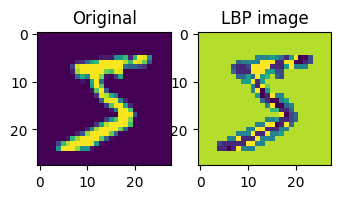

In [183]:
image = x_train[0]
lbp = local_binary_pattern(image, 8, 2 , method = 'uniform')
plt.figure(figsize = (10, 5))
plt.subplot(1,5, 1)
plt.imshow(image)
plt.title('Original')
plt.subplot(1,5,2)
plt.imshow(lbp)
plt.title('LBP image')

## HOG (Histogram  of Oriented Gradients )

In [189]:
from skimage.feature import hog

# Extract Histogram of Oriented Gradients (HOG) features
def extract_hog_features(images):
    hog_features = []
    for image in images:
# Compute HOG features
        hog_image = hog(image, orientations=9,
                pixels_per_cell=(7, 7), 
                 cells_per_block=(2, 2), 
                 visualize=False)
        hog_features.append(hog_image)
    return np.array(hog_features)


In [190]:
x_train_hog = extract_hog_features(x_train)
print(f'Origial shape: {x_train.shape}')
print(f'Hog feature shape: {x_train_hog.shape}')

Origial shape: (60000, 28, 28)
Hog feature shape: (60000, 324)


In [191]:
from skimage import exposure
image = x_train[0]
# Compute HOG features
fd, hog_image = hog(image, orientations=8, pixels_per_cell=(7, 7), cells_per_block=(2, 2), visualize=True)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

Text(0.5, 1.0, 'HOG image')

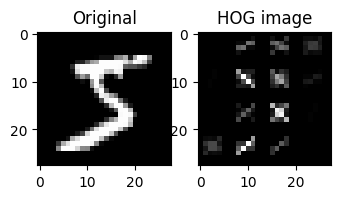

In [192]:
plt.figure(figsize = (10, 5))
plt.subplot(1,5, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.subplot(1,5,2)
plt.imshow(hog_image, cmap = 'gray')
plt.title('HOG image')

## Logistic Regression


In [196]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(max_iter= 1000)
logistic.fit(x_train_hog, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [197]:
from sklearn.metrics import accuracy_score
x_test_hog = extract_hog_features(x_test)
y_predicted = logistic.predict(x_test_hog)
print(f'accuracy score: {accuracy_score(y_predicted, y_test)}')


accuracy score: 0.9732
